In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
def load_titanic_data():
    return (pd.read_csv('/kaggle/input/titanic/train.csv'), pd.read_csv('/kaggle/input/titanic/test.csv'))

train_data, test_data = load_titanic_data()

In [3]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


array([[<Axes: title={'center': 'PassengerId'}>,
        <Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>],
       [<Axes: title={'center': 'Fare'}>, <Axes: >, <Axes: >]],
      dtype=object)

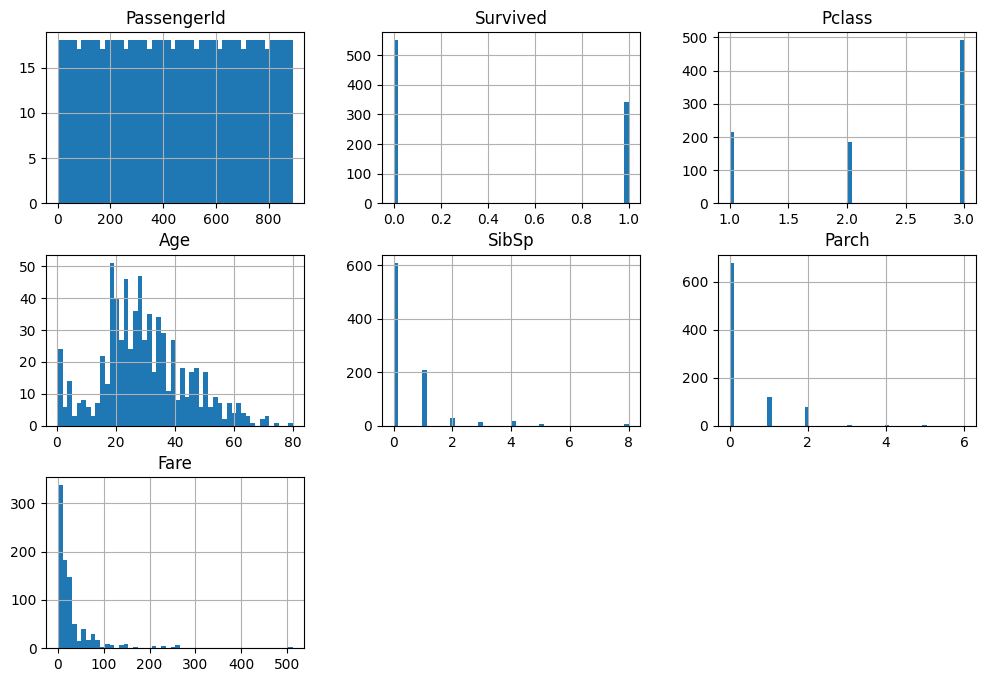

In [6]:
import matplotlib.pyplot as plt

train_data.hist(bins=50, figsize=(12,8))

In [7]:
corr_matrix = train_data.corr(numeric_only=True)

In [8]:
corr_matrix['Survived']

PassengerId   -0.005007
Survived       1.000000
Pclass        -0.338481
Age           -0.077221
SibSp         -0.035322
Parch          0.081629
Fare           0.257307
Name: Survived, dtype: float64

<Axes: xlabel='Sex'>

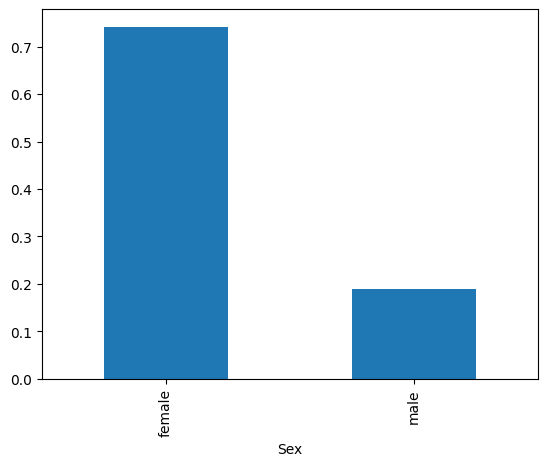

In [9]:
train_data.groupby('Sex')['Survived'].mean().plot(kind='bar')

<Axes: xlabel='Age', ylabel='Survived'>

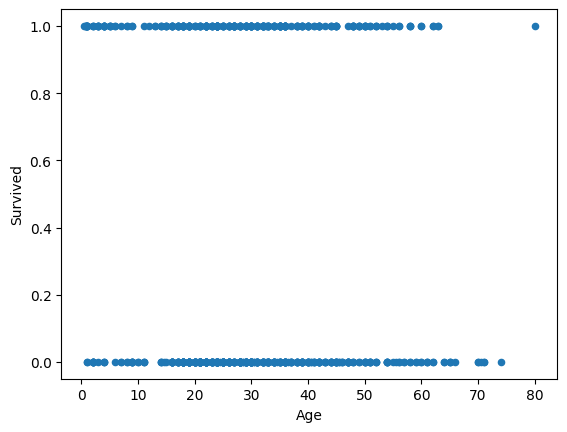

In [10]:
train_data.plot(
    x='Age',
    y='Survived',
    kind='scatter'
)

In [11]:
from scipy.stats.contingency import association

table = pd.crosstab(train_data['Sex'], train_data['Survived'])

association(table, method='cramer')

0.5433513806577551

In [12]:
cat_cols = train_data.select_dtypes(include='object').columns

for col in cat_cols:
    table = pd.crosstab(train_data[col], train_data['Survived'])
    print(col, association(table, method='cramer'))

Name 1.0
Sex 0.5433513806577551
Ticket 0.9275492387400215
Cabin 0.8890675882465788
Embarked 0.17261682709984438


In [13]:
train_data['Pclass'] = train_data['Pclass'].astype('category')

In [14]:
from scipy.stats import chi2_contingency

cat_cols = train_data.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    table = pd.crosstab(train_data[col], train_data['Survived'])   
    chi2, p, dof, expected = chi2_contingency(table)
    print(col, association(table, method='cramer'), chi2, p)

Pclass 0.33981738800531175 102.88898875696056 4.549251711298793e-23
Name 1.0 891.0 0.484248151973633
Sex 0.5433513806577551 260.71702016732104 1.1973570627755645e-58
Ticket 0.9275492387400215 766.5697029458893 0.01152729601163775
Cabin 0.8890675882465788 161.25 0.18357354976388165
Embarked 0.17261682709984438 26.48914983923762 1.769922284120912e-06


In [15]:
train_data['Title'] = train_data['Name'].str.extract(r',\s*([^\.]+)\.')

In [16]:
train_data['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

In [17]:
from scipy.stats import chi2_contingency

cat_cols = train_data.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    table = pd.crosstab(train_data[col], train_data['Survived'])   
    chi2, p, dof, expected = chi2_contingency(table)
    print(col, association(table, method='cramer'), chi2, p)

Pclass 0.33981738800531175 102.88898875696056 4.549251711298793e-23
Name 1.0 891.0 0.484248151973633
Sex 0.5433513806577551 260.71702016732104 1.1973570627755645e-58
Ticket 0.9275492387400215 766.5697029458893 0.01152729601163775
Cabin 0.8890675882465788 161.25 0.18357354976388165
Embarked 0.17261682709984438 26.48914983923762 1.769922284120912e-06
Title 0.580281116661871 300.02302134972405 2.522768232466142e-54


In [18]:
train_data['family_size'] = train_data['SibSp'] + train_data['Parch']

In [19]:
train_data['is_alone'] = (train_data['family_size'] == 0).astype(int)

In [20]:
train_data['is_alone'].value_counts()

is_alone
1    537
0    354
Name: count, dtype: int64

In [21]:
train_data['is_alone'] = train_data['is_alone'].astype('category')

In [22]:
from scipy.stats import chi2_contingency

cat_cols = train_data.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    table = pd.crosstab(train_data[col], train_data['Survived'])   
    chi2, p, dof, expected = chi2_contingency(table)
    print(col, association(table, method='cramer'), chi2, p)

Pclass 0.33981738800531175 102.88898875696056 4.549251711298793e-23
Name 1.0 891.0 0.484248151973633
Sex 0.5433513806577551 260.71702016732104 1.1973570627755645e-58
Ticket 0.9275492387400215 766.5697029458893 0.01152729601163775
Cabin 0.8890675882465788 161.25 0.18357354976388165
Embarked 0.17261682709984438 26.48914983923762 1.769922284120912e-06
Title 0.580281116661871 300.02302134972405 2.522768232466142e-54
is_alone 0.20336708569989195 36.00051446773865 1.9726543846517113e-09


In [23]:
corr_matrix = train_data.corr(numeric_only=True)

In [24]:
corr_matrix['Survived']

PassengerId   -0.005007
Survived       1.000000
Age           -0.077221
SibSp         -0.035322
Parch          0.081629
Fare           0.257307
family_size    0.016639
Name: Survived, dtype: float64

Features:
    Numeric:
        Age, Fare
    Categorical:
        Pclass, Sex, Embarked, Title, is_alone

In [25]:
X = train_data[['Age', 'Fare', 'Name', 'Sex', 'SibSp', 'Parch', 'Pclass']]
y = train_data['Survived']

In [26]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

def numeric_pipeline():
    return make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler()
    )

def cat_pipeline():
    return make_pipeline(
        SimpleImputer(strategy='most_frequent'),
        OneHotEncoder(handle_unknown= 'ignore')
    )

def extract_title(X):
    return np.array([
        name.split(',')[1].split('.')[0].strip()
        for name in X[:, 0]
    ]).reshape(-1, 1)

def title_extractor():
    return make_pipeline(
        SimpleImputer(strategy='most_frequent'),
        FunctionTransformer(extract_title),
        OneHotEncoder(handle_unknown='ignore')
    )
def extract_is_alone(X):
    family_size = X[:, [0]] + X[:, [1]]
    return (family_size == 0).astype(int)

def is_alone_extractor():
    return make_pipeline(
        SimpleImputer(strategy='median'),
        FunctionTransformer(extract_is_alone)
    )

preprocessing = ColumnTransformer([
    ('num', numeric_pipeline(), ['Age', 'Fare']),
    ('title', title_extractor(), ['Name']),
    ('is_alone', is_alone_extractor(), ['SibSp', 'Parch']),
    ('cat', cat_pipeline(), ['Pclass', 'Sex'])
])

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

forest_clf = make_pipeline(preprocessing, RandomForestClassifier(random_state=42))

scores = cross_val_score(forest_clf, X, y, scoring='accuracy', cv=10)

In [28]:
scores.mean()

0.8205118601747815

In [29]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from scipy.stats import randint

full_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('random_forest', RandomForestClassifier(random_state=42))
])

params_distribs = {
    'random_forest__max_features': ['sqrt', 'log2', 0.5],
    'random_forest__max_depth' : [3,4,5,6,7,8],
    'random_forest__min_samples_leaf': [2,4,6,8],
    'random_forest__n_estimators': [100,200,500]
}

rnd_search = RandomizedSearchCV(full_pipeline, params_distribs, n_iter=10, cv=5, scoring='accuracy', random_state=42)

In [30]:
rnd_search.fit(X, y)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('standardscaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Fare']),
                                                                              ('title',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransform...
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['Pclass',
                                                                                'Sex'])])),
                                             ('random_forest',
                                              RandomForestClassifier(random_state=42))]),
                   param_distributions={'random_forest__max_depth': [3, 4, 5, 6,
                                                                     7, 8],
                                        'random_forest__max_features': ['sqrt',
                                                                        'log2',
                                                                        0.5],
                                        'random_forest__min_samples_leaf': [2,
                                                                            4,
                                                                            6,
                                                                            8],
                                        'random_forest__n_estimators': [100,
                                                                        200,
                                                                        500]},
                   random_state=42, scoring='accuracy')

In [31]:
final_model = rnd_search.best_estimator_

In [32]:
from sklearn.metrics import accuracy_score
y_train_pred = final_model.predict(X)

print(accuracy_score(y, y_train_pred))

0.8945005611672279


In [33]:
kaggle_predictions = final_model.predict(test_data)

In [34]:
submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': kaggle_predictions
})

submission.to_csv('submission_2.csv', index=False)

In [35]:
from sklearn.ensemble import GradientBoostingClassifier

gb = Pipeline([
    ('preprocessing', preprocessing),
    ('gradient_boosting', GradientBoostingClassifier(random_state=42))
])

In [36]:
gb_model = gb.fit(X, y)
gb_predictions = gb_model.predict(test_data)
submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': gb_predictions
})

submission.to_csv('submission_3.csv', index=False)

In [37]:
print(accuracy_score(y, gb_model.predict(X)))

0.8933782267115601


In [38]:
params_distribs = {
    'gradient_boosting__n_estimators': [50, 100, 150, 200],
    'gradient_boosting__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'gradient_boosting__max_depth': [1, 2, 3, 4],
    'gradient_boosting__min_samples_leaf': [1, 2, 4, 8],
    'gradient_boosting__min_samples_split': [2, 5, 10],
    'gradient_boosting__subsample': [0.7, 0.8, 1.0]
}

In [39]:
rnd_search_gb = RandomizedSearchCV(
    gb,
    params_distribs,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    random_state=42
)

rnd_search_gb.fit(X, y)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('standardscaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Fare']),
                                                                              ('title',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransform...
                   param_distributions={'gradient_boosting__learning_rate': [0.01,
                                                                             0.03,
                                                                             0.05,
                                                                             0.1,
                                                                             0.2],
                                        'gradient_boosting__max_depth': [1, 2,
                                                                         3, 4],
                                        'gradient_boosting__min_samples_leaf': [1,
                                                                                2,
                                                                                4,
                                                                                8],
                                        'gradient_boosting__min_samples_split': [2,
                                                                                 5,
                                                                                 10],
                                        'gradient_boosting__n_estimators': [50,
                                                                            100,
                                                                            150,
                                                                            200],
                                        'gradient_boosting__subsample': [0.7,
                                                                         0.8,
                                                                         1.0]},
                   random_state=42, scoring='accuracy')

In [40]:
rnd_search_gb.best_params_
rnd_search_gb.best_score_

0.8439897056054235

In [41]:
final_gb = rnd_search_gb.best_estimator_
predictions = final_gb.predict(test_data)

In [42]:
submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': predictions
})

submission.to_csv('submission_4.csv', index=False)

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic = Pipeline([
    ('preprocessing', preprocessing),
    ('logistic', LogisticRegression(max_iter=1000))
])

logistic.fit(X, y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('title',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(func=<function extract_title at 0x...
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(func=<function extract_is_alone at 0x7e1bb620f760>))]),
                                                  ['SibSp', 'Parch']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex'])])),
                ('logistic', LogisticRegression(max_iter=1000))])

In [44]:
print(logistic.score(X, y))

0.8069584736251403


In [45]:
log_predictions = logistic.predict(test_data)

output = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': log_predictions
})

output.to_csv('submission_logistic.csv', index=False)

In [46]:
from scipy.stats import loguniform

params_distribs = {
    'logistic__C': loguniform(0.001, 100)
}

In [47]:
rnd_search_lr = RandomizedSearchCV(
    logistic,
    params_distribs,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    random_state=42
)

rnd_search_lr.fit(X, y)

print(rnd_search_lr.best_params_)
print(rnd_search_lr.best_score_)

{'logistic__C': 21.42302175774105}
0.7946519364760529


In [48]:
rnd_search_lr.best_score_

0.7946519364760529

In [49]:
log_model = rnd_search_lr.best_estimator_
log_predictions = log_model.predict(test_data)

output = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': log_predictions
})

output.to_csv('submission_logistic_2.csv', index=False)